# Analysis of "Azerbaijani Laundromat" transaction data

## set up environment

Load the library dependencies

In [1]:
from collections import defaultdict
from datetime import datetime, timedelta
import itertools
import json
import pathlib
import statistics
import typing
import warnings

from icecream import ic
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import networkx as nx
import polars as pl
import scipy
import seaborn as sns
import watermark

Show a watermark of the OS, hardware, language environment, and dependent library versions.

In [2]:
%load_ext watermark
%watermark
%watermark --iversions

Last updated: 2026-10-08T20:24:47.025956-07:00

Python implementation: CPython
Python version       : 3.13.8
IPython version      : 9.17.1

Compiler    : Clang 17.0.0 (clang-1700.0.13.3)
OS          : Darwin
Release     : 25.6.0
Machine     : arm64
Processor   : arm
CPU cores   : 14
Architecture: 64bit

json      : 2.0.9
matplotlib: 3.11.2
networkx  : 3.7
polars    : 1.44.2
scipy     : 1.18.1
seaborn   : 0.13.2
watermark : 2.6.0



## load the money transfer data

Load the OCCRP data for the "Azerbaijani Laundromat" leaked bank transactions <https://github.com/cj2001/senzing_occrp_mapping_demo/blob/main/occrp_17k.csv>

In [3]:
data_path: pathlib.Path = pathlib.Path("data")

In [4]:
occrp_file: pathlib.Path = data_path / "occrp_17k.csv"
df_orig: pl.DataFrame = pl.read_csv(occrp_file)

In [5]:
df_orig.head()

payer_name,payer_jurisdiction,payer_account,source_file,amount_orig,id,beneficiary_type,beneficiary_core,amount_orig_currency,beneficiary_name,beneficiary_jurisdiction,investigation,beneficiary_bank_country,beneficiary_name_norm,payer_core,beneficiary_account,purpose,date,amount_usd,amount_eur,payer_type,payer_name_norm,payer_bank_country
str,str,str,str,f64,i64,str,bool,str,str,str,str,str,str,bool,str,str,str,i64,str,str,str,str
"""AZARBAYCAN METANOL KOMPANI MMC""","""AZ""","""33817018409333311204""","""pdf/LCM ALLIANCE Account state…",535470.0,6049,"""Company""",true,"""USD""","""LCM ALLIANCE LLP""","""GB""","""az""","""EE""","""LCM ALLIANCE LLP""",false,"""EE27 3300 3335 0561 0002""","""1206295100052180 OCT4121800021…","""2012-06-30""",535470,"""$431,762.31""","""Company""","""AZARBAYCAN METANOL KOMPANI MMC""","""33"""
"""LCM ALLIANCE LLP""","""GB""","""EE27 3300 3335 0561 0002""","""pdf/LCM ALLIANCE Account state…",-535000.0,6050,"""Company""",false,"""USD""","""MOBILA LLP""","""GB""","""az""","""33""","""MOBILA LLP""",true,"""333504500003""","""1207035026699176 INVOICE.No 62…","""2012-07-03""",535000,"""$423,688.44""","""Company""","""LCM ALLIANCE LLP""","""EE"""
"""SKN ELECTRICAL SERVICES LIMITE…","""GB""","""20100374548222""","""pdf/METASTAR Account statement…",90535.19,10623,"""Company""",true,"""USD""","""METASTAR INVEST LLP""","""GB""","""az""","""EE""","""METASTAR INVEST LLP""",false,"""EE77 3300 3334 8704 0004""","""1207065103089249 /FEE/USD4,8…","""2012-07-06""",90536,"""$71,698.53""","""Company""","""SKN ELECTRICAL SERVICES LIMITE…","""20"""
"""METASTAR INVEST LLP""","""GB""","""EE77 3300 3334 8704 0004""","""pdf/METASTAR Account statement…",-90520.0,15589,"""Company""",false,"""USD""","""INMAXO CAPITAL CORP""","""VG""","""az""","""33""","""INMAXO CAPITAL CORP.""",true,"""333455870002""","""1207095022358525 DOGOVOR ZAYMA""","""2012-07-09""",90520,"""$71,686.50""","""Company""","""METASTAR INVEST LLP""","""EE"""
"""METASTAR INVEST LLP""","""GB""","""EE77 3300 3334 8704 0004""","""pdf/METASTAR Account statement…",-60.0,10624,"""Company""",false,"""USD""","""INMAXO CAPITAL CORP""","""VG""","""az""","""33""","""INMAXO CAPITAL CORP.""",true,"""333455870002""","""1207135024578077 DOGOVOR ZAYMA""","""2012-07-13""",60,"""$47.52""","""Company""","""METASTAR INVEST LLP""","""EE"""


## load a thesaurus for "payer" and "beneficiary" names
This is the result of entity resolution plus curation.

In [6]:
rec_file: pathlib.Path = data_path / "backfill.json"

with open(rec_file, "r", encoding = "utf-8") as fp:
   thesaurus: dict[ str, dict ] = json.load(fp)

In [7]:
map_file: pathlib.Path = data_path / "syn_map.json"

with open(map_file, "r", encoding = "utf-8") as fp:
   syn_map: dict[ str, str ] = json.load(fp)

In [8]:
def scrub_name (
    name: str,
    ) -> str:
    """
Scrub the text for people/company names, to get stable lookup keys
    """
    assert isinstance(name, str), name
    return name.replace("  ", " ").strip()

Apply the thesaurus to re-map the names, adding a unique identifier for each entity

In [9]:
pay_uuid_dat: list[ str ] = []
pay_name_dat: list[ str ] = []
ben_uuid_dat: list[ str ] = []
ben_name_dat: list[ str ] = []

for row in df_orig.iter_rows(named = True):
    pay_key: str = scrub_name(row["payer_name"]).lower()

    if pay_key not in syn_map:
        ic(pay_key, row)
    else:
        pay_uuid: str = syn_map[pay_key]
        pay_uuid_dat.append(pay_uuid)
        pay_name_dat.append(thesaurus[pay_uuid]["bods:fullName"])

    ben_key: str = scrub_name(row["beneficiary_name"]).lower()

    if ben_key not in syn_map:
        ic(ben_key, row)
    else:
        ben_uuid: str = syn_map[ben_key]
        ben_uuid_dat.append(ben_uuid)
        ben_name_dat.append(thesaurus[ben_uuid]["bods:fullName"])

Reduce the dataframe to just the slice needed for this analysis

In [10]:
df: pl.DataFrame = df_orig.rename({
    "date": "date_str",
    "payer_account": "pay_account",
    "id": "occrp_id",
    "beneficiary_type": "ben_type",
    "beneficiary_account": "ben_account",
    "payer_type": "pay_type",
})

In [11]:
df = df.with_columns(pl.Series(name = "pay_uuid", values = pay_uuid_dat))
df = df.with_columns(pl.Series(name = "pay_name", values = pay_name_dat))

df = df.with_columns(pl.Series(name = "ben_uuid", values = ben_uuid_dat))
df = df.with_columns(pl.Series(name = "ben_name", values = ben_name_dat))

In [12]:
df = df.with_columns(
    pl.col("date_str").str.to_date().alias("date")
)

In [13]:
df = df.select([
    "date", 
    "amount_usd", 
    "pay_name", 
    "ben_name", 
    "purpose", 
    "occrp_id",
    "pay_uuid", 
    "pay_account", 
    "ben_uuid", 
    "ben_account",
]).sort("date")

In [14]:
df.head()

date,amount_usd,pay_name,ben_name,purpose,occrp_id,pay_uuid,pay_account,ben_uuid,ben_account
date,i64,str,str,str,i64,str,str,str,str
2012-06-30,535470,"""AZARBAYCAN METANOL KOMPANI MMC""","""LCM ALLIANCE LLP""","""1206295100052180 OCT4121800021…",6049,"""f37108f5-b9b7-47ad-8359-0ba0df…","""33817018409333311204""","""073b23b6-0bd6-4b7c-bf35-a97baa…","""EE27 3300 3335 0561 0002"""
2012-07-03,535000,"""LCM ALLIANCE LLP""","""MOBILA LLP""","""1207035026699176 INVOICE.No 62…",6050,"""073b23b6-0bd6-4b7c-bf35-a97baa…","""EE27 3300 3335 0561 0002""","""605a36ae-f8e7-42de-8318-56de9e…","""333504500003"""
2012-07-06,90536,"""SKN ELECTRICAL SERVICES LIMITE…","""METASTAR INVEST LLP""","""1207065103089249 /FEE/USD4,8…",10623,"""01d8ed5e-1141-4802-ae81-f6708d…","""20100374548222""","""9c9772a5-5f5c-475e-b306-e19e24…","""EE77 3300 3334 8704 0004"""
2012-07-09,90520,"""METASTAR INVEST LLP""","""INMAXO CAPITAL CORP""","""1207095022358525 DOGOVOR ZAYMA""",15589,"""9c9772a5-5f5c-475e-b306-e19e24…","""EE77 3300 3334 8704 0004""","""9beefd9a-533e-41b0-8403-f24970…","""333455870002"""
2012-07-13,60,"""METASTAR INVEST LLP""","""INMAXO CAPITAL CORP""","""1207135024578077 DOGOVOR ZAYMA""",10624,"""9c9772a5-5f5c-475e-b306-e19e24…","""EE77 3300 3334 8704 0004""","""9beefd9a-533e-41b0-8403-f24970…","""333455870002"""


In [15]:
azeri_file: pathlib.Path = data_path / "azeri.csv"
df.write_csv(azeri_file, separator = ",")

## descriptive statistics

In [16]:
df.describe()

statistic,date,amount_usd,pay_name,ben_name,purpose,occrp_id,pay_uuid,pay_account,ben_uuid,ben_account
str,str,f64,str,str,str,f64,str,str,str,str
"""count""","""16940""",16940.0,"""16940""","""16940""","""16940""",16940.0,"""16940""","""16940""","""16940""","""16940"""
"""null_count""","""0""",0.0,"""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0"""
"""mean""","""2013-08-30 04:58:32.443919""",360068.349823,null,null,null,8470.5,null,null,null,null
"""std""",null,729466.608789,null,null,null,4890.301115,null,null,null,null
"""min""","""2012-06-30""",1.0,"""A. N. ROHE HOLDING LTD.""","""15747""","""09000014010931 INVOICE 140110""",1.0,"""00c0e6b3-8c99-4fc2-a594-a5a9cd…","""""","""0009d823-6b96-4a94-9d25-8e1790…",""""""
"""25%""","""2013-03-15""",21023.0,null,null,null,4236.0,null,null,null,null
"""50%""","""2013-07-09""",92879.0,null,null,null,8471.0,null,null,null,null
"""75%""","""2014-02-19""",361142.0,null,null,null,12705.0,null,null,null,null
"""max""","""2014-12-31""",2.055997e7,"""ZIWU TRADING CO LIMITED""","""Zmago Jelincic PLEMENITI""","""tagastus Saaja konto on vale""",16940.0,"""ff99c5ba-152c-4731-a00d-c0512b…","""TXID/AZ/1700986181""","""fffd691e-4b3b-4f90-9ad4-8b4cdc…","""TZYH-1207081109814036632"""


In [17]:
float(df["amount_usd"].sum()) / 10**9 / 2.0

3.049778923

In [18]:
pay_set: set[ str ] = set(pl.Series(df.select("pay_uuid")).to_list())
len(pay_set)

407

In [19]:
ben_set: set[ str ] = set(pl.Series(df.select("ben_uuid")).to_list())
len(ben_set)

3361

In [20]:
len(pay_set.union(ben_set))

3643

---
insights:

  * transactions were made between 2012-06-30 and 2014-12-13
  * a total of ~\$3B in money transfers flowed through ~17K transactions
  * mean transfer amount is \$36K
  * max transfer amount is \$20.6M
  * 407 unique payers
  * 3361 unique benficiaries
  * 3643 unique entities overall

## graph construction

construct a graph in `NetworkX` for analysis, while also tallying the transaction flows, amounts, and inter-arrival times

In [21]:
graph: nx.DiGraph = nx.DiGraph()
node_names: list = []

edge_xact: dict = defaultdict(list)

for row in df.iter_rows(named = True):
    src_label: str = row["pay_name"]
    dst_label: str = row["ben_name"]

    if src_label not in node_names:
        node_names.append(src_label)
        src_id: int = node_names.index(src_label)

        graph.add_node(
            src_id,
            name = src_label,
        )            
    else:
        src_id = node_names.index(src_label)

    if dst_label not in node_names:
        node_names.append(dst_label)
        dst_id: int = node_names.index(dst_label)

        graph.add_node(
            dst_id,
            name = dst_label,
        )
    else:
        dst_id = node_names.index(dst_label)

    graph.add_edge(
        src_id,
        dst_id,
    )

    edge_xact[ (src_id, dst_id) ].append({
        "amount": row["amount_usd"],
        "date": datetime.fromisoformat(str(row["date"])),
    })    

In [22]:
for node_id, degree in sorted(nx.degree(graph), key = lambda x: x[1], reverse = True):
    graph.nodes[node_id]["degree"] = degree

## inter-arrival modeling

describe the distributions of transaction inter-arrival times (days in-between) and amounts

In [23]:
summary_data: list = []
timing_data: list = []

for edge, dat in edge_xact.items():        
    dates: list = sorted([
        xact["date"]
        for xact in dat
    ], reverse = False)

    inter_arrival: list = [
        (pair[1] - pair[0]).days
        for pair in itertools.pairwise(dates)
    ]

    timing_data.extend(inter_arrival)

    amounts: list = [
        xact["amount"]
        for xact in dat
    ]

    summary_data.append({
        "src_id": edge[0],
        "dst_id": edge[1],
        "median_amount": statistics.median(amounts),
        "total_amount": sum(amounts),
    })

df_summary: pl.DataFrame = pl.DataFrame(summary_data)
df_summary.head()

src_id,dst_id,median_amount,total_amount
i64,i64,f64,i64
0,1,112760.0,1557547
1,2,445750.0,891500
3,4,46398.0,926234
4,5,45290.0,90580
6,4,225850.0,464978


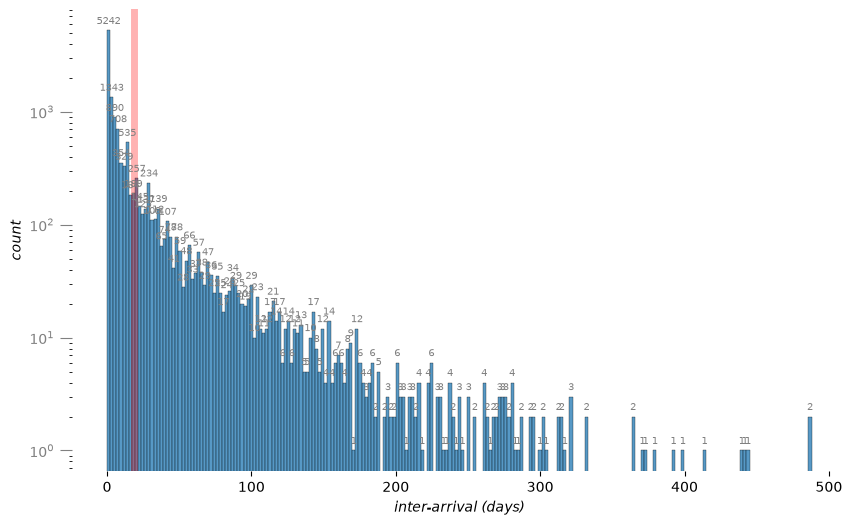

In [24]:
fig, ax = plt.subplots(figsize = (10, 6))
plt.rcParams["font.family"] = "sans-serif"

y = sns.histplot(timing_data)
y.tick_params(axis = "y", size = 9, colors = "gray")
y.bar_label(y.containers[0], padding = 3, color = "gray", fontsize = 7)

plt.xlabel("inter-arrival (days)", size = 10, fontstyle = "italic")
plt.ylabel("count", size = 10, fontstyle = "italic")

sns.despine(bottom = True, left = True)

plt.axvline(x = statistics.mean(timing_data), color = "red", lw = 5, alpha = 0.3)
plt.yscale("log")

plt.legend([], [], frameon = False);

In [25]:
max(timing_data)

488

In [26]:
min(timing_data)

0

In [27]:
statistics.mean(timing_data)

18.42303181924791

In [28]:
statistics.median(timing_data)

4

In [29]:
statistics.stdev(timing_data)

38.36679073546573

In [30]:
df_summary.describe()

statistic,src_id,dst_id,median_amount,total_amount
str,f64,f64,f64,f64
"""count""",4149.0,4149.0,4149.0,4149.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",849.139311,1682.23355,132475.114485,1.4701e6
"""std""",932.560556,1116.225,485761.7225,2.0812e7
"""min""",0.0,1.0,1.0,1.0
"""25%""",4.0,674.0,10425.0,15000.0
"""50%""",4.0,1747.0,32646.0,52385.0
"""75%""",1856.0,2642.0,100000.0,214094.0
"""max""",3639.0,3642.0,2.055997e7,1.2401e9


In [31]:
q = (
    df.lazy()
    .group_by("date")
    .agg(
        pl.len().alias("count"),
        pl.col("amount_usd").sum().alias("total"),
    )
    .sort("date", descending = False)
)

df_date = q.collect()

df_date.head()

date,count,total
date,u32,i64
2012-06-30,1,535470
2012-07-03,1,535000
2012-07-06,1,90536
2012-07-09,1,90520
2012-07-13,3,465009


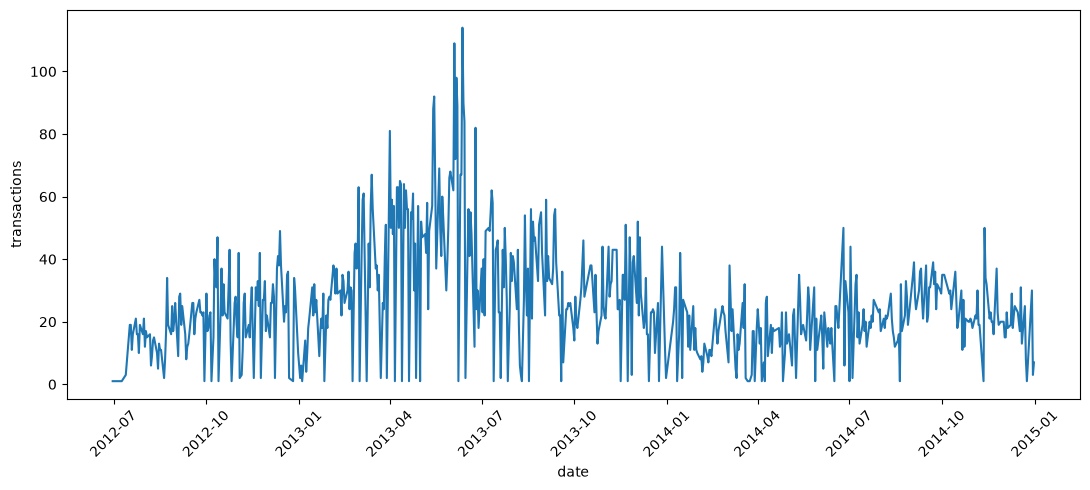

In [32]:
plt.figure(figsize = (11, 5))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sns.lineplot(
        data = df_date,
        x = "date",
        y = "count",
    )

plt.ylabel("transactions")
plt.xlabel("date")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

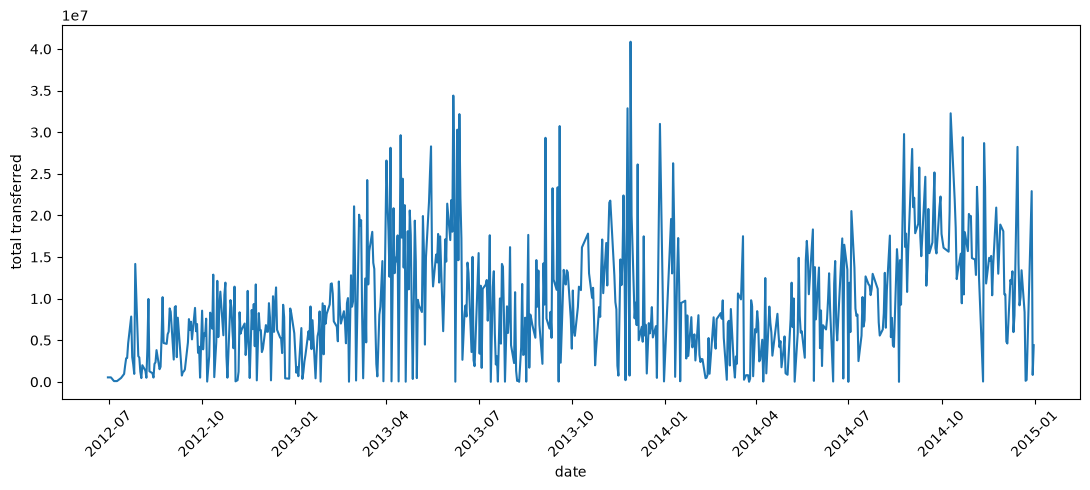

In [33]:
plt.figure(figsize = (11, 5))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sns.lineplot(
        data = df_date,
        x = "date",
        y = "total",
    )

plt.ylabel("total transferred")
plt.xlabel("date")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

In [34]:
df_date.sort("count", descending = True).head(10)

date,count,total
date,u32,i64
2013-06-12,114,32171514
2013-06-04,109,21847204
2013-06-06,98,34397151
2013-05-15,92,28294711
2013-06-13,90,22122935
2013-06-07,89,26013301
2013-05-14,88,25181413
2013-06-14,84,17231575
2013-06-25,82,15015356


In [35]:
df_date.sort("total", descending = True).head(10)

date,count,total
date,u32,i64
2013-11-28,39,40870127
2013-06-06,98,34397151
2013-11-25,47,32869474
2014-10-10,24,32269381
2013-06-12,114,32171514
2013-12-27,44,30997006
2013-09-19,36,30733395
2013-06-10,67,30300802
2014-08-25,22,29772918


---
insights:

  * largest count of daily transactions was during mid June 2013
  * largest total daily amounts transferred was during late November 2013
  * mean total transfer between two nodes is \$1.47M
  * max total transfer is \$1.24B
  * mean of the median transfer amount between two nodes is \$132k
  * exponential distribution for inter-arrival times (days)
	 * min 0
	 * median 4
	 * mean 18.42
	 * max 488
	 * stdev 38.37

## approximating a "general ledger"

apply basic accounting practices to model the in-flows, out-flows, and resulting balances

In [36]:
for node_id in graph.nodes():
    graph.nodes[node_id]["count"] = 0
    graph.nodes[node_id]["volume"] = 0
    graph.nodes[node_id]["credits"] = 0
    graph.nodes[node_id]["debits"] = 0

for row in df_summary.iter_rows(named = True):
    src_id: int = row["src_id"]
    dst_id: int = row["dst_id"]
    amount: float = float(row["total_amount"])

    graph.nodes[src_id]["count"] += 1
    graph.nodes[src_id]["volume"] += amount
    graph.nodes[src_id]["debits"] += amount

    graph.nodes[dst_id]["count"] += 1
    graph.nodes[dst_id]["volume"] += amount
    graph.nodes[dst_id]["credits"] += amount

for node_id in graph.nodes():
    graph.nodes[node_id]["balance"] = round(graph.nodes[node_id]["credits"] - graph.nodes[node_id]["debits"], 2)

In [37]:
nodes_dat: typing.List[ dict ] = [
    dat
    for _, dat in graph.nodes(data = True)
]

df_nodes: pl.DataFrame = pl.DataFrame(nodes_dat).sort("volume", descending = True)
df_nodes.head()

name,degree,count,volume,credits,debits,balance
str,i64,i64,f64,f64,f64,f64
"""HILUX SERVICES LP""",1204,1204,3.1271e9,1.5394e9,1.5877e9,-4.8322707e7
"""LCM ALLIANCE LLP""",1124,1124,1.7060e9,8.60794229e8,8.45191172e8,1.5603057e7
"""BAKTELEKOM MMC""",2,2,1.4529e9,0.0,1.4529e9,-1.4529e9
"""METASTAR INVEST LLP""",1354,1354,8.43414975e8,3.88838611e8,4.54576364e8,-6.5737753e7
"""POLUX MANAGEMENT LP""",474,474,7.14315702e8,3.81192733e8,3.33122969e8,4.8069764e7


In [38]:
df_nodes.describe()

statistic,name,degree,count,volume,credits,debits,balance
str,str,f64,f64,f64,f64,f64,f64
"""count""","""3643""",3643.0,3643.0,3643.0,3643.0,3643.0,3643.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,2.277793,2.277793,3.3486e6,1.6743e6,1.6743e6,0.0
"""std""",null,36.142827,36.142827,6.6945e7,3.1312e7,3.9624e7,2.4887e7
"""min""","""15747""",1.0,1.0,58.0,0.0,0.0,-1.4529e9
"""25%""",null,1.0,1.0,14367.0,8937.0,0.0,7798.0
"""50%""",null,1.0,1.0,50810.0,38778.0,0.0,37224.0
"""75%""",null,1.0,1.0,211407.0,149602.0,0.0,141376.0
"""max""","""Zmago Jelincic PLEMENITI""",1354.0,1354.0,3.1271e9,1.5394e9,1.5877e9,1.18928408e8


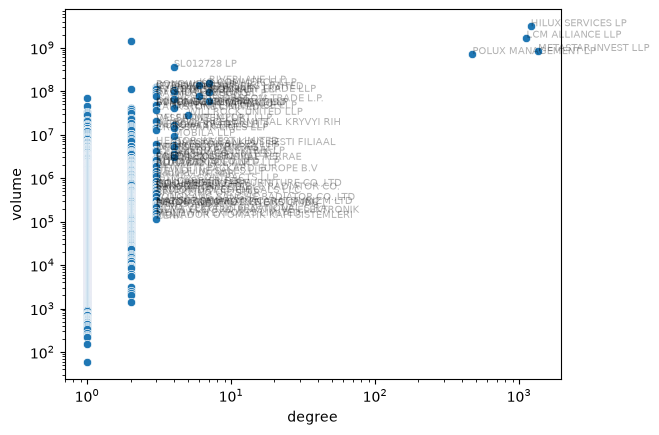

In [39]:
x: list = df_nodes["degree"].to_list()
y: list = df_nodes["volume"].to_list()
labels: list = df_nodes["name"].to_list()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sns.scatterplot(data = df_nodes, x = "degree", y = "volume")

plt.yscale("log")
plt.xscale("log")

for i, label in enumerate(labels):
    if x[i] > 2: # only label the top-ranked 14 companies
        plt.annotate(label, (x[i], y[i]), alpha = 0.3, fontsize = 7)

plt.show()

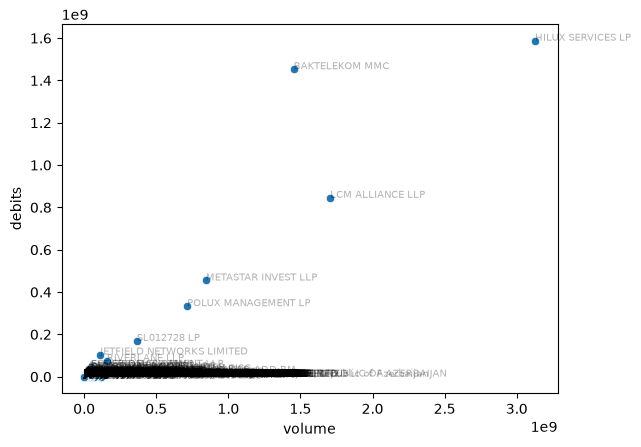

In [40]:
x: list = df_nodes["volume"].to_list()
y: list = df_nodes["debits"].to_list()
labels: list = df_nodes["name"].to_list()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sns.scatterplot(data = df_nodes, x = "volume", y = "debits")

for i, label in enumerate(labels):
    plt.annotate(label, (x[i], y[i]), alpha = 0.3, fontsize = 7)

plt.show()

this chart illustrates the "sources" (negative balance, below center) and "drains" (positive balance, above center)

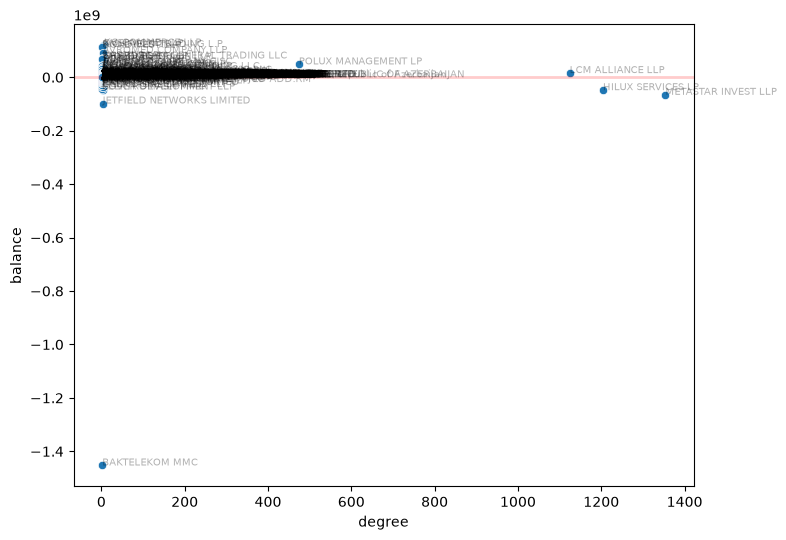

In [41]:
x: list = df_nodes["degree"].to_list()
y: list = df_nodes["balance"].to_list()
labels: list = df_nodes["name"].to_list()

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams["font.family"] = "sans-serif"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sns.scatterplot(data = df_nodes, x = "degree", y = "balance")

for i, label in enumerate(labels):
    plt.annotate(label, (x[i], y[i]), alpha = 0.3, fontsize = 7)

plt.axhline(y = 0, color = "red", lw = 2, alpha = 0.2)

plt.show()

---
insights:

  * mean credits/debits transferred through a given node is \$1.67M
  * mean count of transfers through a given node is 2.28
  * funds appear to have sourced through many shell companies, with "BAKTELEKOM MMC" being the largest
  * funds appear to have drained from "LCM", "HILUX", "POLUX", and "METASTAR"

## centrality measure

calculate _betweenness centrality_ measures for each node

In [42]:
ranks: dict = nx.betweenness_centrality(
    graph,
    weight = "volume",
    normalized = True,
    endpoints = True,
)

for node_id, rank in sorted(ranks.items(), key = lambda x: x[1], reverse = True):
    rank = round(rank, 4)
    graph.nodes[node_id]["rank"] = rank

    if rank > 0.0003:
        print(f"rank {rank:.4f}",  graph.nodes[node_id]["name"])

rank 0.0686 LCM ALLIANCE LLP
rank 0.0532 METASTAR INVEST LLP
rank 0.0395 HILUX SERVICES LP
rank 0.0118 POLUX MANAGEMENT LP
rank 0.0087 GLOBECOM TRADE L.P.
rank 0.0060 RIVERLANE LLP
rank 0.0052 MOLONEY TRADE LLP
rank 0.0031 REDPARK SALES CORP
rank 0.0028 DANSKE BANK A/S EESTI FILIAAL
rank 0.0028 OVERMOND LLP
rank 0.0028 DELFRONT IMPORT LLP
rank 0.0028 INFOCAR TRADE LLP
rank 0.0025 WILLROCK UNITED LLP
rank 0.0019 DATEMILE ALLIANCE LLP
rank 0.0011 KG COMMERCE LLP
rank 0.0011 LUXBORG L.P.
rank 0.0009 AVROMED COMPANY LLP
rank 0.0007 SIRONA DENTAL SYSTEMS GMBH
rank 0.0007 INTERWEST L.P.
rank 0.0005 ZENIT
rank 0.0004 EUROEX COMMERCIAL LLP
rank 0.0004 PJSC ARCELORMITTAL KRYVYI RIH
rank 0.0004 DELOKALI LIMITED
rank 0.0004 CAPTRON MERCHANTS LLP
rank 0.0004 SANTRAL ELEKTRIK LP
rank 0.0004 BONWILL PROJECTS LLP
rank 0.0004 KAI YUAN TRADING CO LIMITED RM289 1
rank 0.0004 PINGCHUAN TRADE CO., LIMITED ADD:RM
rank 0.0004 BONDWEST LLP
rank 0.0004 MARAK CO LIMITED


## simple graph analytics

now we have some descriptive stats to use for modeling a simulation of these kinds of transactions; let's look into other potential parameters for simulation, based on graph analytics

In [43]:
nx.diameter(graph.to_undirected())

4

In [44]:
nx.density(graph)

0.00031271183796326233

In [45]:
nx.girth(graph.to_undirected())

1

In [46]:
node_degree: typing.List[ int ] = dict(nx.degree(graph)).values()
max(node_degree)

1354

let's look in detail at the relatively higher degree nodes

In [47]:
for node_id, degree in sorted(nx.degree(graph), key = lambda x: x[1], reverse = True):
    if degree >= 3:
        print(f"{degree:3}\t{graph.nodes[node_id]}")

1354	{'name': 'METASTAR INVEST LLP', 'degree': 1354, 'count': 1354, 'volume': 843414975.0, 'credits': 388838611.0, 'debits': 454576364.0, 'balance': -65737753.0, 'rank': 0.0532}
1204	{'name': 'HILUX SERVICES LP', 'degree': 1204, 'count': 1204, 'volume': 3127099139.0, 'credits': 1539388216.0, 'debits': 1587710923.0, 'balance': -48322707.0, 'rank': 0.0395}
1124	{'name': 'LCM ALLIANCE LLP', 'degree': 1124, 'count': 1124, 'volume': 1705985401.0, 'credits': 860794229.0, 'debits': 845191172.0, 'balance': 15603057.0, 'rank': 0.0686}
474	{'name': 'POLUX MANAGEMENT LP', 'degree': 474, 'count': 474, 'volume': 714315702.0, 'credits': 381192733.0, 'debits': 333122969.0, 'balance': 48069764.0, 'rank': 0.0118}
  7	{'name': 'GLOBECOM TRADE L.P.', 'degree': 7, 'count': 7, 'volume': 58599178.0, 'credits': 41948760.0, 'debits': 16650418.0, 'balance': 25298342.0, 'rank': 0.0087}
  7	{'name': 'RIVERLANE LLP', 'degree': 7, 'count': 7, 'volume': 157450248.0, 'credits': 83573651.0, 'debits': 73876597.0, 'bal

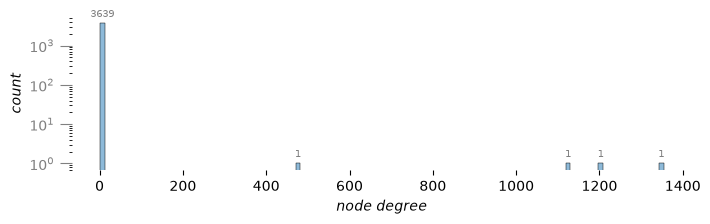

In [48]:
fig, ax = plt.subplots(figsize = (8, 2))

y = sns.histplot(node_degree)
y.tick_params(axis = "y", size = 9, colors = "gray")
y.bar_label(y.containers[0], padding = 3, color = "gray", fontsize = 7)

plt.xlabel("node degree", size = 10, fontstyle = "italic")
plt.ylabel("count", size = 10, fontstyle = "italic")

sns.despine(bottom = True, left = True)
plt.yscale("log")

plt.legend([], [], frameon = False);

---
insights:

  * this is a sparse, directed graph, with cycles
  * the graph is not wide, `diameter = 4`
  * there's a "power law"-ish distribution on node degree

## components and paths

In [49]:
for clique in nx.connected_components(graph.to_undirected()):
    print(clique)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [50]:
len(list(nx.strongly_connected_components(graph)))

3519

In [51]:
strong_edges: list = []

for clique in nx.strongly_connected_components(graph):
    if len(clique) > 1:
        strong_edges.append(sorted(list(clique)))
        print("\n", clique)
        print(len(clique), "\n")

        for node_id in clique:
            dat: dict = graph.nodes[node_id]
            print(f"{node_id:4}", dat["name"])


 {1, 2, 4, 7, 1032, 9, 2061, 528, 16, 2067, 532, 1046, 27, 2077, 2079, 32, 2081, 2082, 2083, 1060, 33, 38, 39, 1570, 2090, 43, 1583, 2100, 54, 1079, 1080, 2616, 2102, 1595, 2108, 1084, 1087, 2117, 78, 593, 3156, 598, 3158, 1631, 1632, 1633, 2145, 99, 1123, 609, 104, 3182, 116, 3195, 1660, 136, 31, 2206, 1184, 169, 175, 177, 179, 1716, 1750, 1756, 1757, 220, 221, 2790, 759, 248, 2807, 251, 764, 2813, 1790, 1279, 1280, 260, 279, 792, 283, 290, 3375, 817, 1842, 309, 1856, 2883, 1864, 841, 337, 3410, 2388, 345, 2907, 2407, 877, 2928, 370, 882, 1917, 1407, 1922, 2436, 2951, 398, 2958, 915, 2970, 1439, 1954, 934, 2491, 3007, 464, 474, 475, 3035, 1004, 2544, 2548, 2555, 510}
125 

   1 LCM ALLIANCE LLP
   2 MOBILA LLP
   4 METASTAR INVEST LLP
   7 JETFIELD NETWORKS LIMITED
1032 KAI YUAN TRADING CO LIMITED RM289 1
   9 LOTA SALES LLP
2061 BRIGHT LINE MARITIME LLP
 528 OVERMOND LLP
  16 LINSTAR SYSTEMS CORP.
2067 DRINKSTAR GMBH
 532 STREAMFORD WORLDWIDE LIMITED
1046 FESTIVAL SALES LLP
  27 DAN

In [52]:
path_counts: typing.List[ int ] = [
    len(path[1]) + 1
    for path in nx.all_pairs_all_shortest_paths(graph)
]

In [53]:
sorted(set(path_counts))

[2, 3362, 3363]

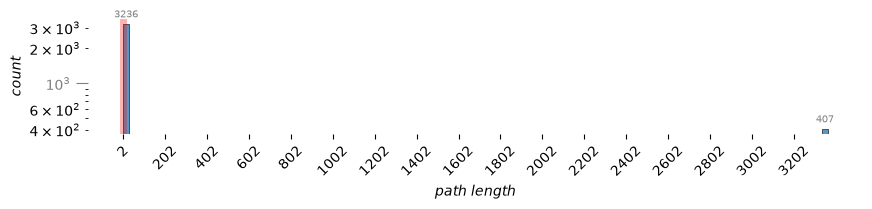

In [54]:
fig, ax = plt.subplots(figsize = (10, 1.5))

y = sns.histplot(path_counts)
y.tick_params(axis = "y", size = 9, colors = "gray")
y.bar_label(y.containers[0], padding = 3, color = "gray", fontsize = 7)

plt.xlabel("path length", size = 10, fontstyle = "italic")
plt.ylabel("count", size = 10, fontstyle = "italic")

plt.axvline(x = statistics.median(path_counts), color = "red", lw = 5, alpha = 0.3)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x)))
y.set(xticks = range(min(path_counts), max(path_counts) + 1, 200))
plt.xticks(rotation = 45)

sns.despine(bottom = True, left = True)
plt.yscale("log")

plt.legend([], [], frameon = False);

---
insights:

  * it's a fully connected graph
  * for most node pairs `path length =< 2`
  * there is 1 strongly connected component, which has 125 members

## flow analysis

In [55]:
nx.flow_hierarchy(graph)

0.920703784044348

since most of the nodes are on the periphery, what's happening in-between them?

In [56]:
for node_id in nx.center(graph.to_undirected()):
    print(f"{node_id:4}", graph.nodes[node_id])

center: list[ int ] = [
    node_id
    for node_id in nx.center(graph.to_undirected())
]

 104 {'name': 'GLOBECOM TRADE L.P.', 'degree': 7, 'count': 7, 'volume': 58599178.0, 'credits': 41948760.0, 'debits': 16650418.0, 'balance': 25298342.0, 'rank': 0.0087}
 179 {'name': 'KG COMMERCE LLP', 'degree': 6, 'count': 6, 'volume': 137267184.0, 'credits': 128097796.0, 'debits': 9169388.0, 'balance': 118928408.0, 'rank': 0.0011}
 370 {'name': 'RIVERLANE LLP', 'degree': 7, 'count': 7, 'volume': 157450248.0, 'credits': 83573651.0, 'debits': 73876597.0, 'balance': 9697054.0, 'rank': 0.006}
 609 {'name': 'LUXBORG L.P.', 'degree': 6, 'count': 6, 'volume': 77136925.0, 'credits': 72690481.0, 'debits': 4446444.0, 'balance': 68244037.0, 'rank': 0.0011}
 882 {'name': 'MOLONEY TRADE LLP', 'degree': 7, 'count': 7, 'volume': 96843881.0, 'credits': 81295576.0, 'debits': 15548305.0, 'balance': 65747271.0, 'rank': 0.0052}


In [57]:
neg_bal: int = 0  # sources
pos_bal: int = 0  # drains
zed_bal: int = 0  # conduits

for node_id in nx.periphery(graph.to_undirected()):
    dat: dict = graph.nodes[node_id]

    if dat["balance"] < 0:
        neg_bal += 1
    elif dat["balance"] > 0:
        pos_bal += 1
    else:
        zed_bal += 1

ic(neg_bal, pos_bal, zed_bal);

ic| neg_bal: 303, pos_bal: 3212, zed_bal: 13


In [58]:
len(graph.nodes)

3643

In [59]:
len(list(nx.periphery(graph.to_undirected())))

3528

In [60]:
non_periph: set = set(graph.nodes) - set(nx.periphery(graph.to_undirected()))

details: dict = {
    node_id: graph.nodes[node_id]
    for node_id in non_periph
}

for node_id, dat in sorted(details.items(), key = lambda pair: pair[1]["rank"], reverse = True):
    print(dat)

{'name': 'LCM ALLIANCE LLP', 'degree': 1124, 'count': 1124, 'volume': 1705985401.0, 'credits': 860794229.0, 'debits': 845191172.0, 'balance': 15603057.0, 'rank': 0.0686}
{'name': 'METASTAR INVEST LLP', 'degree': 1354, 'count': 1354, 'volume': 843414975.0, 'credits': 388838611.0, 'debits': 454576364.0, 'balance': -65737753.0, 'rank': 0.0532}
{'name': 'HILUX SERVICES LP', 'degree': 1204, 'count': 1204, 'volume': 3127099139.0, 'credits': 1539388216.0, 'debits': 1587710923.0, 'balance': -48322707.0, 'rank': 0.0395}
{'name': 'POLUX MANAGEMENT LP', 'degree': 474, 'count': 474, 'volume': 714315702.0, 'credits': 381192733.0, 'debits': 333122969.0, 'balance': 48069764.0, 'rank': 0.0118}
{'name': 'GLOBECOM TRADE L.P.', 'degree': 7, 'count': 7, 'volume': 58599178.0, 'credits': 41948760.0, 'debits': 16650418.0, 'balance': 25298342.0, 'rank': 0.0087}
{'name': 'RIVERLANE LLP', 'degree': 7, 'count': 7, 'volume': 157450248.0, 'credits': 83573651.0, 'debits': 73876597.0, 'balance': 9697054.0, 'rank': 0

---
insights:

  * most of the nodes are in the periphery are "sources" (negative balance) and none are "drains" (end with a positive balance)

  * 5 intermediary nodes don't rank as high in centrality as the 4 "drain" shell companies mentioned in the investigative journalism articles
     * these 5 are in the computed "center" of the graph
     * what patterns of transactions flow through these?

## directed flows

In [61]:
for node_id in graph.nodes():
    deg: int = graph.in_degree(node_id)

    if deg > 0:
        dat = graph.nodes[node_id]
        print(f"{deg:3} in degree {node_id:3}", dat["name"])

248 in degree   1 LCM ALLIANCE LLP
  2 in degree   2 MOBILA LLP
127 in degree   4 METASTAR INVEST LLP
  1 in degree   5 INMAXO CAPITAL CORP
  1 in degree   7 JETFIELD NETWORKS LIMITED
  1 in degree   8 ERREBI SPA
  2 in degree   9 LOTA SALES LLP
  1 in degree  10 ELEATEX TRADING S.L.
  1 in degree  11 CST KIMYA SANAYI VE TICARET AS
  1 in degree  12 SILVEA SCHIATTI+C.SRL
  1 in degree  13 EGE KUR.KAMU FIN.VE TIC.MRKZ.SB.
  1 in degree  14 UNIVAR
  1 in degree  15 MERTIK MAXITROL GMBH&CO KG
  1 in degree  16 LINSTAR SYSTEMS CORP.
  1 in degree  17 OOO MAYAKPRINT
  1 in degree  18 IMEX MOTORS L.L.C
  1 in degree  19 CAHAN ISTANBUL DIS.TIC.LTD
  1 in degree  20 MTG HANDELS UND CONSULTING GMBH
  1 in degree  21 HEYER Medical AG
  1 in degree  22 ORBI GROUP LTD
  1 in degree  23 FASEPHARMATEK S.R.L
  1 in degree  24 CHRISTEL HEILMANN GMBH&CO.KG
  1 in degree  25 IVANOVS LAW COMPANY LLC
  1 in degree  26 DORNIER MEDTECH EUROPE GMBH
  1 in degree  27 DANSKE BANK A/S EESTI FILIAAL
  1 in degre

In [62]:
for node_id in graph.nodes():
    deg: int = graph.out_degree(node_id)
    graph.nodes[node_id]["out_deg"] = deg

label the "role" for each node

In [63]:
for node_id in graph.nodes():
    if graph.out_degree(node_id) > 100:
        graph.nodes[node_id]["role"] = "drain"
    elif graph.nodes[node_id]["balance"] < 0:
        graph.nodes[node_id]["role"] = "source"
    else:
        graph.nodes[node_id]["role"] = "shuffle"

In [64]:
flows_dat: list = [
    {
        "node_id": node_id,
        "name": dat["name"],
        "role": dat["role"],
        "out_deg": dat["out_deg"],
        "balance": dat["balance"],
        "count": dat["count"],
        "volume": dat["volume"],
        "credits": dat["credits"],
        "debits": dat["debits"],        
    }
    for node_id, dat in graph.nodes(data = True)
    if dat["out_deg"] > 0
]

df_flows: pl.DataFrame = pl.DataFrame(flows_dat)
df_flows.head()

node_id,name,role,out_deg,balance,count,volume,credits,debits
i64,str,str,i64,f64,i64,f64,f64,f64
0,"""AZARBAYCAN METANOL KOMPANI MMC""","""source""",1,-1.557547e6,1,1.557547e6,0.0,1.557547e6
1,"""LCM ALLIANCE LLP""","""drain""",876,1.5603057e7,1124,1.7060e9,8.60794229e8,8.45191172e8
2,"""MOBILA LLP""","""source""",2,-2.438438e6,4,9.362528e6,3.462045e6,5.900483e6
3,"""SKN ELECTRICAL SERVICES LIMITE…","""source""",1,-926234.0,1,926234.0,0.0,926234.0
4,"""METASTAR INVEST LLP""","""drain""",1227,-6.5737753e7,1354,8.43414975e8,3.88838611e8,4.54576364e8


In [65]:
df_flows.describe()

statistic,node_id,name,role,out_deg,balance,count,volume,credits,debits
str,f64,str,str,f64,f64,f64,f64,f64,f64
"""count""",407.0,"""407""","""407""",407.0,407.0,407.0,407.0,407.0,407.0
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1305.459459,null,null,10.194103,-2.9094e6,11.719902,2.7064e7,1.2077e7,1.4987e7
"""std""",965.64997,null,null,96.07873,7.4238e7,107.780955,1.9883e8,9.2939e7,1.1783e8
"""min""",0.0,"""A. N. ROHE HOLDING LTD.""","""drain""",1.0,-1.4529e9,1.0,605.0,0.0,1.0
"""25%""",484.0,null,null,1.0,-1.244493e6,1.0,93000.0,0.0,60600.0
"""50%""",1046.0,null,null,1.0,-147406.0,1.0,549000.0,0.0,348470.0
"""75%""",2061.0,null,null,1.0,-2032.0,2.0,3.136614e6,50000.0,2.116215e6
"""max""",3639.0,"""ZIWU TRADING CO LIMITED""","""source""",1227.0,1.18928408e8,1354.0,3.1271e9,1.5394e9,1.5877e9


In [66]:
df_flows.group_by(["role"]).agg(pl.col("node_id").count())  

role,node_id
str,u32
"""shuffle""",90
"""drain""",4
"""source""",313


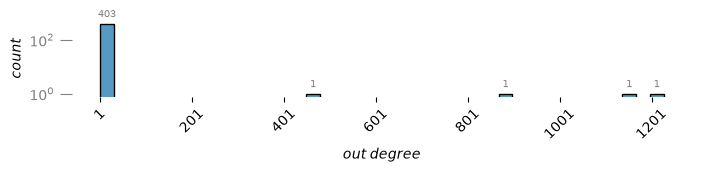

In [67]:
dat = df_flows["out_deg"].to_list()

fig, ax = plt.subplots(figsize = (8, 1))
plt.rcParams["font.family"] = "sans-serif"

y = sns.histplot(dat)
y.tick_params(axis = "y", size = 9, colors = "gray")
y.bar_label(y.containers[0], padding = 3, color = "gray", fontsize = 7)

plt.xlabel("out degree", size = 10, fontstyle = "italic")
plt.ylabel("count", size = 10, fontstyle = "italic")

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: int(x)))
y.set(xticks = range(min(dat), max(dat) + 1, 200))
plt.xticks(rotation = 45)

sns.despine(bottom = True, left = True)
plt.yscale("log")

plt.legend([], [], frameon = False);

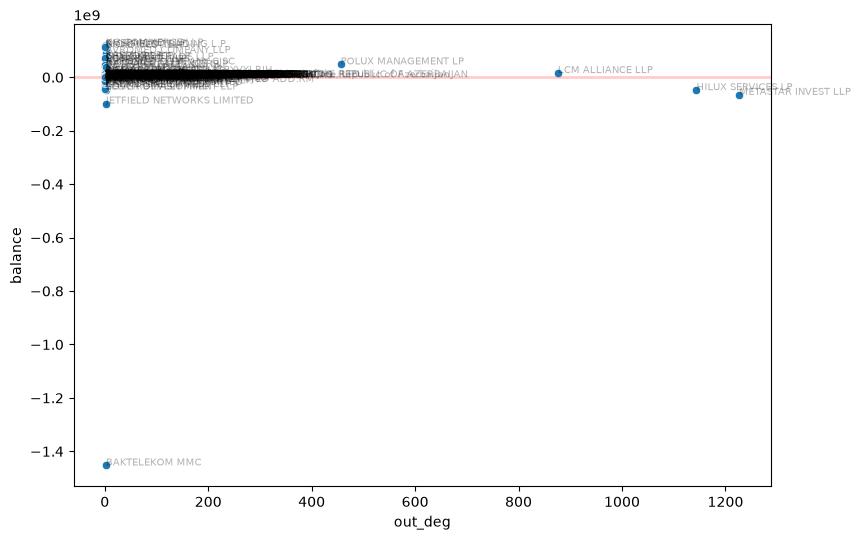

In [68]:
x: list = df_flows["out_deg"].to_list()
y: list = df_flows["balance"].to_list()
labels: list = df_flows["name"].to_list()

fig, ax = plt.subplots(figsize = (9, 6))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sns.scatterplot(data = df_flows, x = "out_deg", y = "balance")

for i, label in enumerate(labels):
    plt.annotate(label, (x[i], y[i]), alpha = 0.3, fontsize = 7)

plt.axhline(y = 0, color = "red", lw = 2, alpha = 0.2)
plt.show()

here are the shell companies which had more funds transferred out than transferred in

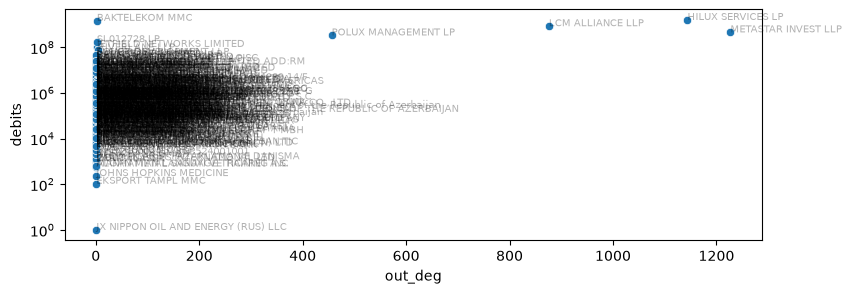

In [69]:
x: list = df_flows["out_deg"].to_list()
y: list = df_flows["debits"].to_list()
labels: list = df_flows["name"].to_list()

fig, ax = plt.subplots(figsize = (9, 3))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sns.scatterplot(data = df_flows, x = "out_deg", y = "debits")

for i, label in enumerate(labels):
    plt.annotate(label, (x[i], y[i]), alpha = 0.3, fontsize = 7)

plt.yscale("log")
plt.show()

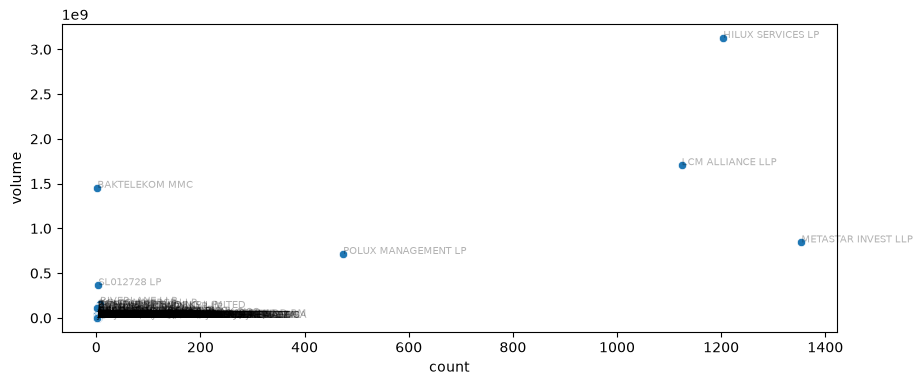

In [70]:
x: list = df_flows["count"].to_list()
y: list = df_flows["volume"].to_list()
labels: list = df_flows["name"].to_list()

fig, ax = plt.subplots(figsize = (10, 4))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sns.scatterplot(data = df_flows, x = "count", y = "volume")

for i, label in enumerate(labels):
    if x[i] > 1:
        plt.annotate(label, (x[i], y[i]), alpha = 0.3, fontsize = 7)

plt.show()

---
insights:

  * role "source" = 313
  * role "shuffle" = 90
  * role "drain" = 4

## triadic census

In [71]:
for triad, occurrences in sorted(nx.triadic_census(graph).items(), key = lambda x: x[1], reverse = True):
    if occurrences > 0:
        print(f"triad {triad:>5}: {occurrences:7d} occurrences")

triad   003: 8038953910 occurrences
triad   012: 9836725 occurrences
triad  021D: 1759213 occurrences
triad   102:  331006 occurrences
triad  021C:  297398 occurrences
triad  111U:  128009 occurrences
triad  021U:   21970 occurrences
triad  111D:   15575 occurrences
triad   201:    2851 occurrences
triad  120U:     215 occurrences
triad   210:      26 occurrences
triad  120D:      16 occurrences
triad  030T:      14 occurrences
triad   300:      12 occurrences
triad  120C:       1 occurrences


<img
 src="https://figures.semanticscholar.org/6ebe86cdf25f3b58dd98dd9c1c00c3f5c2491734/2-Figure1-1.png"
 style="height:500px"
/>

---
insights:

  * do the many `021D` triads indicate "burst in beneficiaries" AML tradecraft pattern?

## serialize results

In [72]:
occrp_file: pathlib.Path = data_path / "occrp.json"

with open(occrp_file, "w") as fp:  # pylint: disable=W1514                                                                                                    
    dat: dict = nx.node_link_data(
        graph,
        edges = "edges", # for forward compatibility                                                                                                          
    )

    json.dump(
        dat,
        fp,
        indent = 2,
        ensure_ascii = False,
    )

## summary

#### graph shape:

  * this is a sparse, directed graph, with cycles
  * the graph is not wide, `diameter = 4`
  * there's a "power law"-ish distribution on node degree
  * it's a fully connected graph
  * for most node pairs `path length =< 2`
  * there is 1 strongly connected component, which has 125 members
  * follow-up question: do the many `021D` triads indicate "burst in beneficiaries" AML tradecraft pattern?


#### money transfers:

  * transactions were made between 2012-06-30 and 2014-12-13
     * 407 unique payers
     * 3361 unique benficiaries
     * 3643 unique entities overall
  * a total of ~\$3B in money transfers flowed through ~17K transactions
  * largest count of daily transactions was during mid June 2013
  * largest total daily amounts transferred was during late November 2013
  * mean transfer amount is \$36K
  * max transfer amount is \$20.6M
  * max total transfer is \$1.24B
  * mean of the median transfer amount between two nodes is \$132k
  * mean total transfer between two nodes is \$1.47M
  * mean transferred through a given node is \$1.67M
  * mean count of transfers through a given node is 2.28
  * exponential distribution for inter-arrival times (days)
	 * min 0
	 * median 4
	 * mean 18.42
	 * max 488
	 * stdev 38.37

#### shell company strategy:

  * funds appear to have sourced through many shell companies, with "BAKTELEKOM MMC" being the largest
  * funds drained into 4 companies: "LCM ALLIANCE LLP", "METASTAR INVEST LLP", "POLUX MANAGEMENT LP", "HILUX SERVICES LP"
  * roles of the shell companies:
	* "source" 313
	* "shuffle" 90 (transfers to 2+ other companies)
	* "drain" 4
  * most of the nodes are in the periphery are "sources" (negative balance) and none are "drains" (end with a positive balance)
  * the "center" of the graph has 5 intermediary nodes which do not rank as high in centrality as the 4 "drain" shell companies mentioned in the investigative journalism articles
     * these 5 are in the computed "center" of the graph
     * follow-up question: what patterns of transactions flow through these?

OCCRP analysis and the subsequent investigative journalism articles mention these 4 top shell companies involved in the "Azerbaijani Laundromat"

Leaked transaction data came from an Estonian branch of Danske Bank, which is one of the "shuffle" nodes: "DANSKE BANK A/S EESTI FILIAAL" <https://thebanks.eu/banks/13002>

See also:

- <https://github.com/ikwattro/occrp-azerbaijani-laundromat-dataset>
- <https://gijn.org/stories/how-they-did-it-the-azerbaijani-laundromat/>